In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from utilities import *

Dimension de X:  (100, 2)
Dimension de y:  (100, 1)


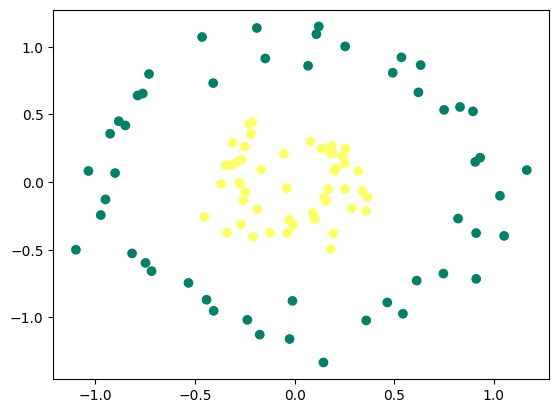

In [2]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

# Modif
X[:,1] = X[:,1]*10

print("Dimension de X: ", X.shape)
print("Dimension de y: ", y.shape)

plt.scatter(X[:,0], X[:,1], c=y, cmap="summer")
plt.show()

In [3]:
""" Modif """
lim = 10
h = 100
W1 = np.linspace(-lim,lim,h)
W2 = np.linspace(-lim,lim,h)

W11, W22 = np.meshgrid(W1, W2)

W_final = np.c_[W11.ravel(), W22.ravel()].T
W_final.shape

(2, 10000)

In [4]:
""" Modif """
b = 0
Z = X.dot(W_final) + b
A = 1/(1 + np.exp(-Z))

epsilon = 1e-15
L = 1/len(y)*np.sum(-y*np.log(A+epsilon) - (1-y)*np.log(1-A+epsilon), axis=0).reshape(W11.shape)
L.shape

(100, 100)

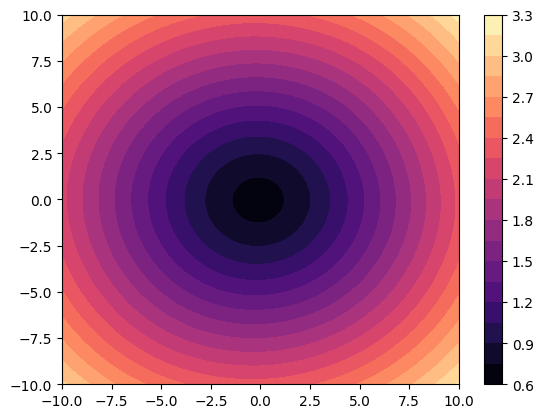

In [5]:
""" Modif """
plt.contourf(W11, W22, L, 20, cmap="magma")
plt.colorbar()

In [6]:
def initializer(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [7]:
def model(X, W, b):
    Z = X.dot(W) + b
    A = 1/(1 + np.exp(-Z))
    return A

In [8]:
def log_loss(A, y):
    return 1/len(y)*np.sum(-y*np.log(A) - (1-y)*np.log(1-A))

In [9]:
def gradiants(A, X, y):
    dW = 1/len(y)*np.dot(X.T, A-y)
    db = 1/len(y)*np.sum(A-y)
    return (dW, db)

In [10]:
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate*dW
    b = b - learning_rate*db
    return (W, b)

In [11]:
def predict(X, W, b):
    A = model(X, W, b)
    return (A>=0.5, A)

In [12]:
from sklearn.metrics import accuracy_score

In [13]:
def artifitial_neuron(X, y, learning_rate = 0.1, n_iter = 100):
    #Initialization
    W, b = initializer(X)

    Loss = []

    for i in range(n_iter):
        A = model(X, W, b)
        Loss.append(log_loss(A, y))
        dW, db = gradiants(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)

    y_pred, y_pred_prob = predict(X, W, b)

    print(accuracy_score(y, y_pred))

    plt.plot(Loss)
    plt.show()

    return (W, b)

0.48


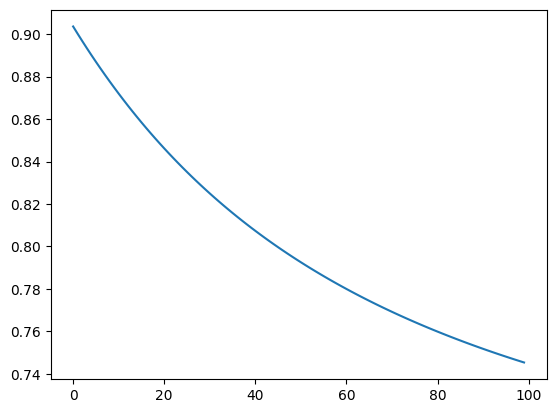

In [14]:
W, b = artifitial_neuron(X, y)

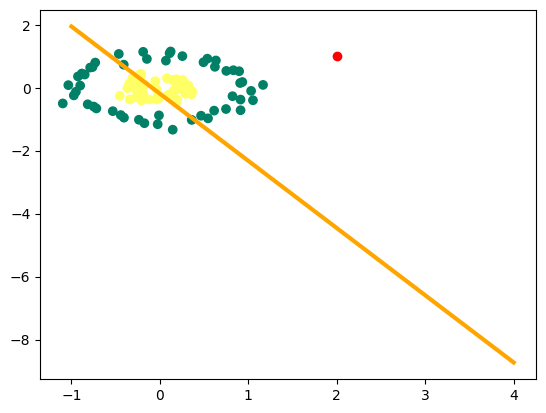

(array([False]), array([0.04288257]))

In [15]:
new_plant = np.array([2,1])

x0 = np.linspace(-1, 4, 100)
x1 = (-W[0]*x0 -b)/W[1]

plt.plot(x0, x1, c="orange", lw=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap="summer")
plt.scatter(new_plant[0], new_plant[1], c="r")
plt.show()

predict(new_plant, W, b)